In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from sklearn.datasets import load_iris 
# Load iris dataset from sklearn 
iris = load_iris()

In [ ]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names) 
df['target'] = iris.target  # Add the target variable 
# Display the first few rows 
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
133,6.3,2.8,5.1,1.5,2
104,6.5,3.0,5.8,2.2,2
28,5.2,3.4,1.4,0.2,0
53,5.5,2.3,4.0,1.3,1
95,5.7,3.0,4.2,1.2,1


In [ ]:
df.head()
df.isnull().sum()
df.describe()
df.sample(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
136,6.3,3.4,5.6,2.4,2
62,6.0,2.2,4.0,1.0,1
16,5.4,3.9,1.3,0.4,0
119,6.0,2.2,5.0,1.5,2
71,6.1,2.8,4.0,1.3,1
137,6.4,3.1,5.5,1.8,2
85,6.0,3.4,4.5,1.6,1
51,6.4,3.2,4.5,1.5,1
3,4.6,3.1,1.5,0.2,0
110,6.5,3.2,5.1,2.0,2


In [ ]:
#  Check the structure and summary of the DataFrame 
# Displays columns, non-null counts, and data types for each column 
df.info() 
#  Check for missing/null values in each column 
# Returns a count of missing values per column 
df.isnull().sum() 
#  Generate descriptive statistics for numerical features 
# transpose() flips rows and columns to make the output easier to read 
df.describe().transpose() 
# Check for duplicate rows in the dataset
# Returns the number of completely duplicated rows 
df.duplicated().sum() 
# Check the data types of each column 
# Helps identify if any columns need conversion (e.g., strings to datetime or category) 
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

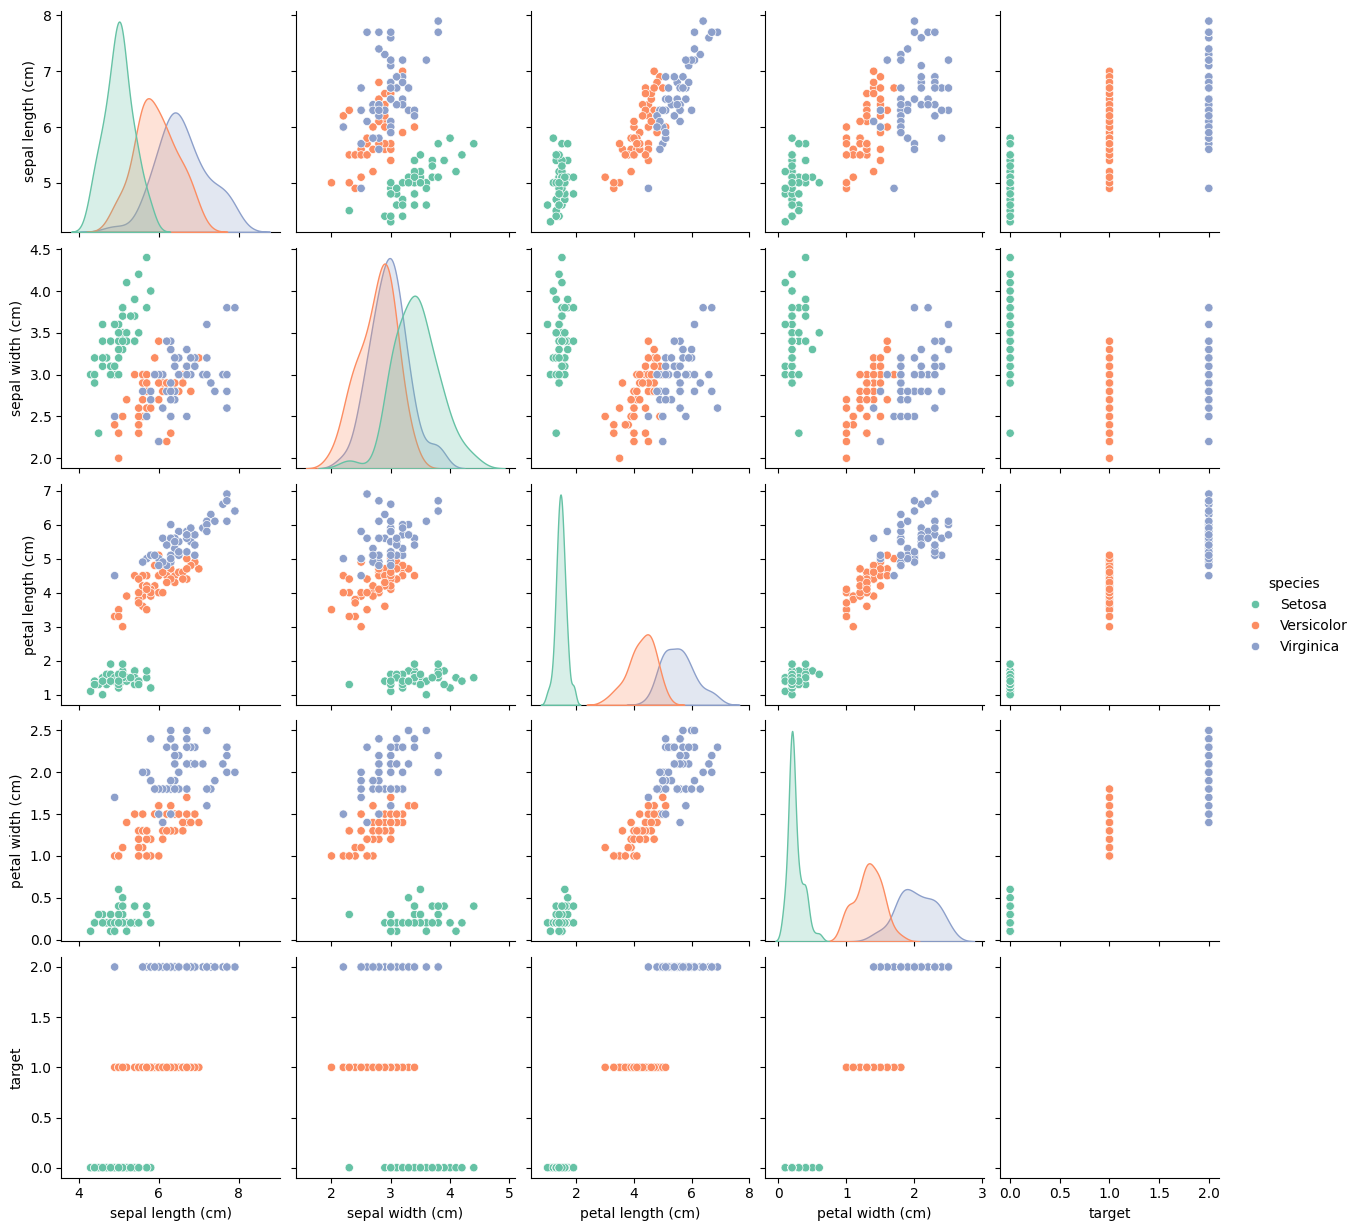

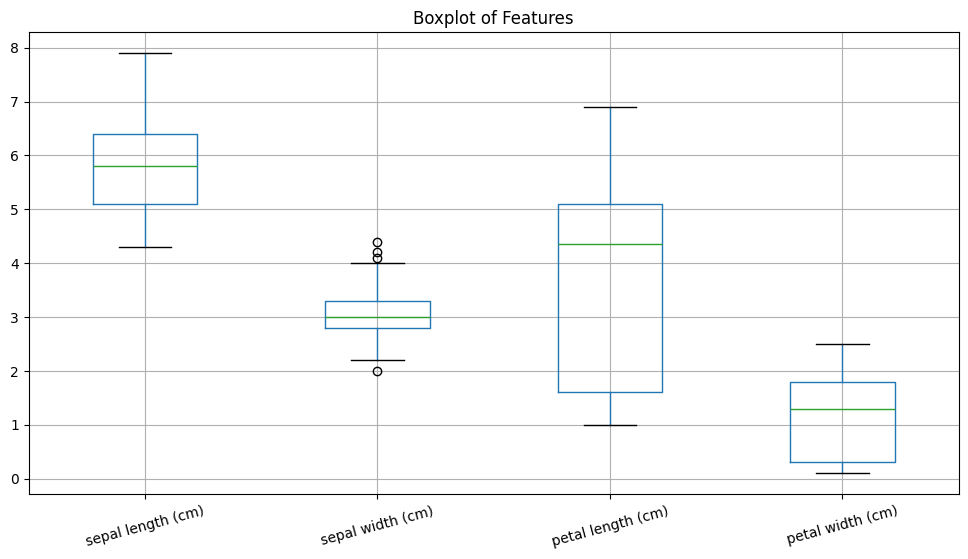

<Figure size 1000x800 with 0 Axes>

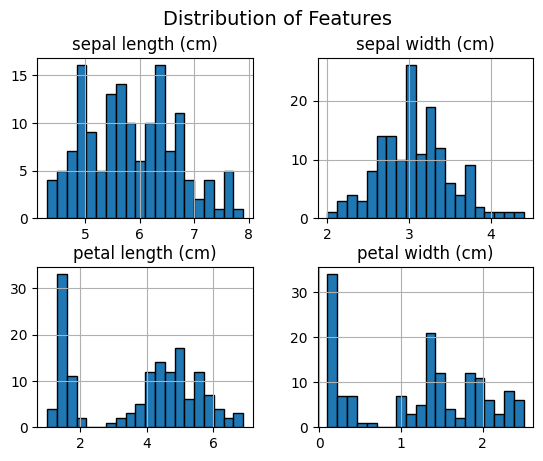

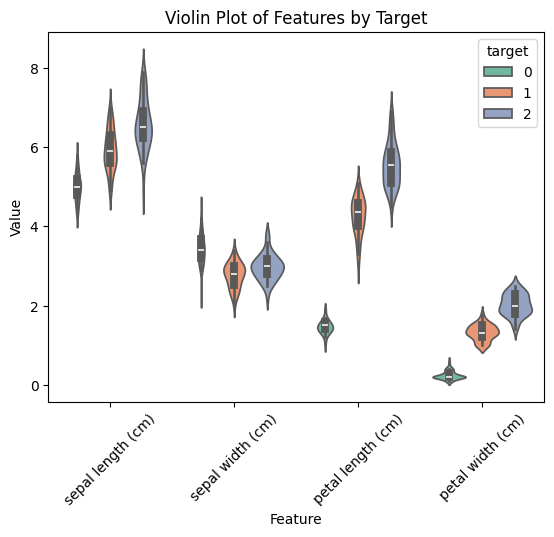

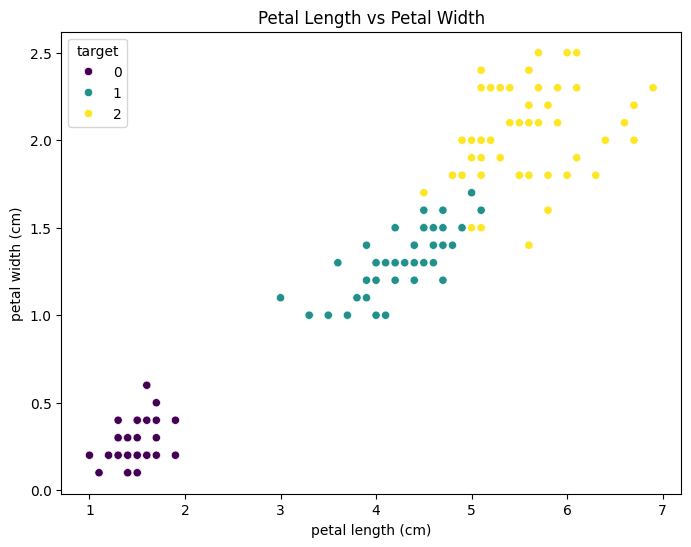

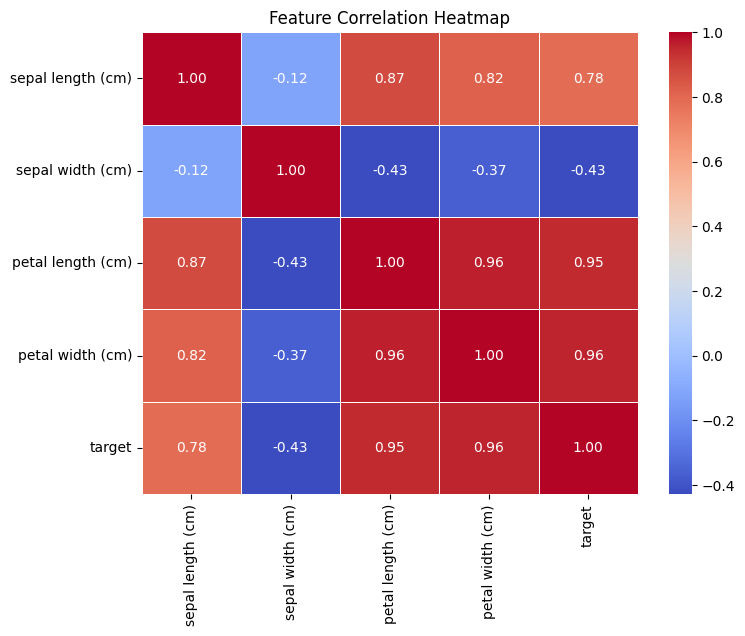

In [ ]:
#  Count the number of samples in each target class (0, 1, 2) 
df['target'].value_counts() 
#  Import seaborn and matplotlib for visualization 
import seaborn as sns 
import matplotlib.pyplot as plt 
#  Map numerical target labels to flower species names for easier interpretation in plots 
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}) 
#  Create a pairplot to visualize the relationship between all pairs of features, colored by 
#species 
sns.pairplot(df, hue='species', palette='Set2') 
plt.show() 
#  Create a boxplot to visualize the spread (distribution, outliers, etc.) of each feature 
plt.figure(figsize=(12, 6)) 
df.drop(columns=['target']).boxplot() 
plt.title("Boxplot of Features") 
plt.xticks(rotation=15) 
plt.show() 
# Plot histograms to see the distribution of values for each feature 
plt.figure(figsize=(10, 8)) 
df.drop(columns=['target']).hist(bins=20, edgecolor='black') 
plt.suptitle("Distribution of Features", fontsize=14) 
plt.show() 
#  Create a violin plot to show distribution and probability density of features by target class 
# First, we need to melt the DataFrame into long format for seaborn 
feature_cols = df.drop(columns=['target', 'species']).columns

df_melted = df.melt(id_vars=['target'], value_vars=feature_cols, var_name='Feature', value_name='Value')

# Plot the violin plot for each feature grouped by target
sns.violinplot(x="Feature", y="Value", hue="target", data=df_melted, palette="Set2")
plt.xticks(rotation=45) 
plt.title("Violin Plot of Features by Target") 
plt.show() 
# Scatter plot for petal length vs. petal width colored by target class 
plt.figure(figsize=(8,6)) 
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'], hue=df["target"], 
palette="viridis") 
plt.title("Petal Length vs Petal Width") 
plt.show()
#  Heatmap showing correlation between all features and target 
plt.figure(figsize=(8,6)) 
sns.heatmap(df.drop(columns=['species']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) 
plt.title("Feature Correlation Heatmap") 
plt.show()

Splitting the data

In [ ]:
#  Splitting the dataset into features and target 
# X will contain all the input features (everything except the target column) 
X = df.drop(columns=['target']) 
# y will contain the output/label we're trying to predict (target column) 
y = df['target']  # Target (class labels: 0, 1, 2 for flower species) 
#  Splitting the dataset into training and testing sets 
# 80% of the data will be used for training the model (X_train, y_train) 
# 20% will be used to evaluate/test the model (X_test, y_test) 
# random_state=42 ensures reproducibility of the split (same result every time) 
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler 
# Step 1: Create a StandardScaler object 
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train) 
 
X_test = scaler.transform(X_test)

Model Training And Evaluation

Logistic Regration

In [ ]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
# Initialize the Logistic Regression model 
log_reg = LogisticRegression() 
# Train the model using training data 
log_reg.fit(X_train, y_train) 
# Predict the labels for test set 
y_pred_log = log_reg.predict(X_test) 
# Evaluate the model's performance 
accuracy_log_reg = accuracy_score(y_test, y_pred_log)  # Accuracy Score 
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log)  # Confusion Matrix 
class_report_log_reg = classification_report(y_test, y_pred_log)  # Classification Report 

# Print evaluation metrics 

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.2f}") 
print("Confusion Matrix:") 
print(conf_matrix_log_reg) 
print("Classification Report:") 
print(class_report_log_reg)

Logistic Regression Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Decision Tree Classifier

In [ ]:
# Import Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier 
# Initialize the Decision Tree model 
tree_clf = DecisionTreeClassifier() 
# Train the model 
tree_clf.fit(X_train, y_train) 
# Predict labels for test set 
y_pred_tree = tree_clf.predict(X_test) 
# Evaluate the model 
accuracy_tree = accuracy_score(y_test, y_pred_tree) 
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree) 
class_report_tree = classification_report(y_test, y_pred_tree) 
# Print evaluation metrics 
print(f'Decision Tree Accuracy: {accuracy_tree:.2f}') 
print('Confusion Matrix:') 
print(conf_matrix_tree) 
print('Classification Report:')

Decision Tree Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:


3. k-Nearest Neighbors (k-NN): 

In [ ]:
# Import k-NN Classifier 
from sklearn.neighbors import KNeighborsClassifier 
# Initialize k-NN model with 5 neighbors 
knn_clf = KNeighborsClassifier(n_neighbors=5) 
# Train the model 
knn_clf.fit(X_train, y_train) 
# Predict labels for test set 
y_pred_knn = knn_clf.predict(X_test) 
# Evaluate the model 
accuracy_knn = accuracy_score(y_test, y_pred_knn) 
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn) 
class_report_knn = classification_report(y_test, y_pred_knn) 
# Print evaluation metrics 
print(f'k-NN Accuracy: {accuracy_knn:.2f}') 
print('Confusion Matrix:') 
print(conf_matrix_knn) 
print('Classification Report:') 
print(class_report_knn) 

k-NN Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Visualizing the Confusion metrices :

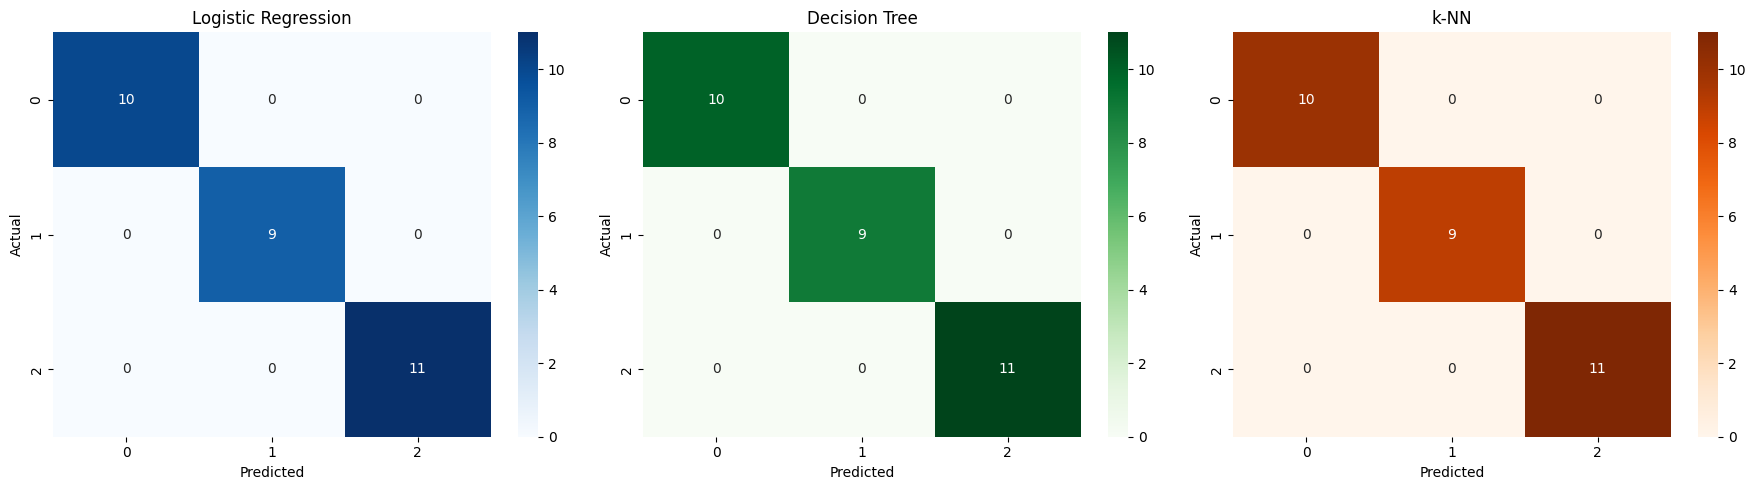

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# Create a subplot with 1 row and 3 columns for visualizing 3 confusion matrices 
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
# Plot confusion matrix for Logistic Regression 
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', ax=axes[0]) 
axes[0].set_title('Logistic Regression') 
axes[0].set_xlabel('Predicted') 
axes[0].set_ylabel('Actual') 
# Plot confusion matrix for Decision Tree 
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1]) 
axes[1].set_title('Decision Tree') 
axes[1].set_xlabel('Predicted') 
axes[1].set_ylabel('Actual') 
# Plot confusion matrix for k-Nearest Neighbors 
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[2]) 
axes[2].set_title('k-NN') 
axes[2].set_xlabel('Predicted') 
axes[2].set_ylabel('Actual') 
# Display the plots 
plt.tight_layout() 
plt.show()

Saving the Best Model

In [ ]:
import pickle
 
# Save the model
with open('log_reg_model.pkl', 'wb') as model_file:
    pickle.dump(log_reg, model_file)
 
# Save the scaler  ← THIS WAS MISSING
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
 
# Now load them back
with open('log_reg_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)
 
with open('scaler.pkl', 'rb') as scaler_file:
    loaded_scaler = pickle.load(scaler_file)
 

In [ ]:
# Import necessary libraries
import pickle
import pandas as pd
# ---------------------------
# Load the trained model and scaler
# ---------------------------
def load_model_and_scaler(model_filename='iris_model.pkl',
scaler_filename='iris_scaler.pkl'):
 """Loads the trained model and scaler from pickle files."""
 
 # Load the trained model from file (update with correct file name if needed)
 with open(model_filename, 'rb') as model_file:
   model = pickle.load(model_file) # Deserialize model
 # Load the StandardScaler used during training
 with open(scaler_filename, 'rb') as scaler_file:
  scaler = pickle.load(scaler_file) # Deserialize scaler
 
 return model, scaler
# ---------------------------
# Preprocess input using the loaded scaler
# ---------------------------
def preprocess_input(input_data, scaler):
 """Preprocess the input data: convert to DataFrame and scale it using the loaded scaler."""
 
 # Convert the input dictionary to a single-row DataFrame
 input_df = pd.DataFrame([input_data])
 
 # Apply the same scaling used during training
 input_scaled = scaler.transform(input_df)
 
 return input_scaled
# ---------------------------
# Predict the Iris species
# ---------------------------
def predict_iris_species(input_data):
 """Predicts the species of the Iris flower (Setosa, Versicolor, or Virginica)."""
 
 # Load the trained model and scaler
 model, scaler = load_model_and_scaler(
    model_filename='log_reg_model.pkl',
    scaler_filename='scaler.pkl'
 )
 
 # Preprocess input (apply scaling)
 input_scaled = preprocess_input(input_data, scaler)
 
 # Predict the species (returns 0, 1, or 2)
 prediction = model.predict(input_scaled)
 
 # Map numerical prediction to actual species name
 species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
 predicted_species = species_map[prediction[0]]
 
 return predicted_species
# ---------------------------
# Example Usage
# ---------------------------
# New input sample to classify
new_iris_data = {
 'sepal length (cm)': 7.0,
 'sepal width (cm)': 3.2,
 'petal length (cm)': 4.7,
 'petal width (cm)': 1.4
}
#7.0,3.2,4.7,1.4,
# Call the prediction function
result = predict_iris_species(new_iris_data)
print(f"The predicted species is: {result}")
 

The predicted species is: versicolor
